<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex03_YOLO_%EC%84%B8%EA%B7%B8%EB%A9%98%ED%8A%B8%ED%83%90%EC%A7%80(%EC%B0%A8%EB%9F%89%ED%8C%8C%EC%86%90).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 목표
- image sementation 이해하기
- 탐지하는 객체에 포함되는 픽셀들위 위치를 예측하는 기술
- 디테일한 영역 탐지가 가능함: 차량파손, 자율주행, 의료영상 등 활용
- YOLOv11 내부의 segment task를 수행해보기

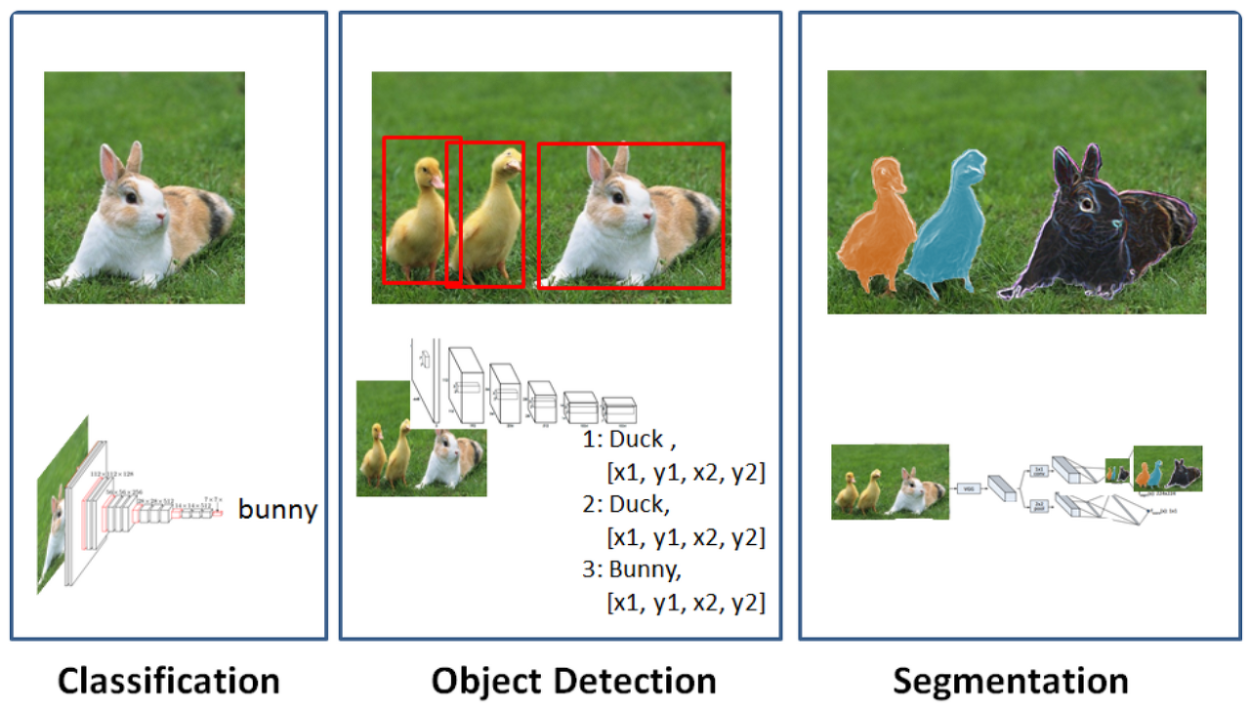

### Segmentation 기술이 예측을 수행하는 원리
- 픽셀단위로 학습하고 예측을 수행함
- 각 픽셀이 어떤 범주에 속하는지 확률값을 예측

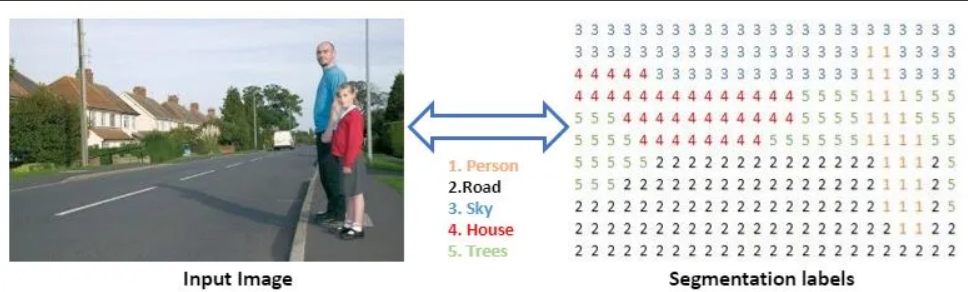

### Segmentation 기술의 종류
- Semantic Segmentation : 같은 의미를 가지는 픽셀끼리만 구분하는 기술. 객체(대상)를 구별하지 않음
- Instance Segmentation : 같은 의미를 가지더라도 객체를 구별해서 분할하여 예측(탐지)을 진행하는 기술


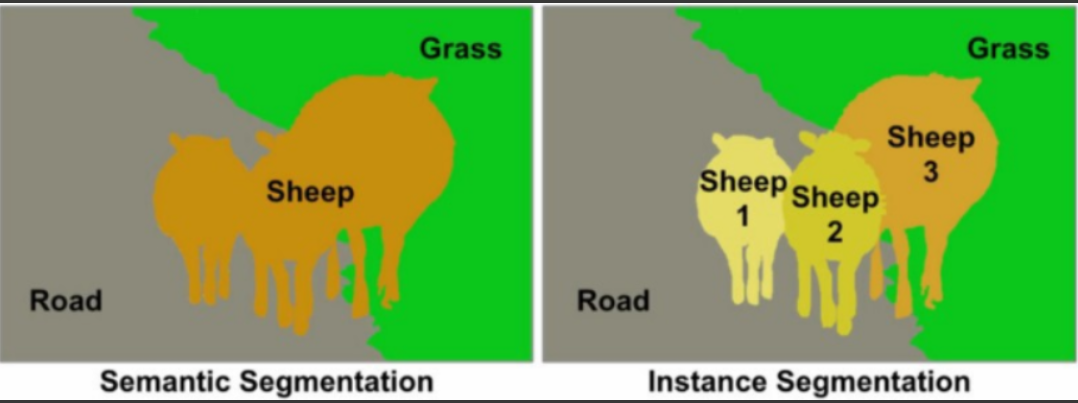

### 실습_차량파손범위 예측
- 활용사례: 쏘카 (https://tech.socarcorp.kr/data/2020/02/13/car-damage-segmentation-model.html)
- 학습데이터: https://universe.roboflow.com/ysdb/car-jxbzt-fbne2/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

In [ ]:
!pip install roboflow


In [ ]:
# 활용법
# 다운로드 데이터셋> 코드스니펫 or zip 파일 형태로 내려받기(3번째 탭)
# > 기존 사용법이랑 동일하게 colab 코드 붙여넣기 > 실행!

In [ ]:
# gpu
# 드라이브
# yolo 폴더 경로 이동!

%cd '/content/drive/MyDrive/YOLO_study'

/content/drive/MyDrive/YOLO_study


In [ ]:
train: /content/drive/MyDrive/YOLO_study/car-1/train/images
val: /content/drive/MyDrive/YOLO_study/car-1/valid/images
test: /content/drive/MyDrive/YOLO_study/car-1/valid/images

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="tmAh5QzDRBNU1SaiTFYa")
project = rf.workspace("none-n1imd").project("car-jxbzt")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car-1 in yolov11:: 100%|██████████| 671/671 [00:04<00:00, 138.37it/s]


In [ ]:
# data.yml 파일 경로 변경
# train, val, test 폴더의 경로를 절대경로로 맞춰주기
# 무조건 변경해주기!

In [ ]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
# 모델을 불러오기 위한 클래스 (기능의 묶음)

# Load a model
# model = YOLO("yolo11n-seg.yaml")  # build a new model from YAML
model = YOLO("yolo11n-seg.pt")  # load a pretrained model (recommended for training)
# model = YOLO("yolo11n-seg.yaml").load("yolo11n.pt")  # build from YAML and transfer weights

# Train the model
results = model.train(data="./car-1/data.yaml", epochs=100, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./car-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

In [ ]:
# 모델 활용
# ./runs/segment/train/weights/best.pt

best = YOLO('./runs/segment/train/weights/best.pt')

best

YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_runni

In [ ]:
# 마지막 부분 탐지 클래스 개수 표현x
# 학습 측면에서는 커스텀 데이터셋의 14개 class 구분 하고 있음

In [ ]:
rs = best('./car-1/valid/images/12062929_1_jpg.rf.4d659d535812f21d6709d19fd8bf79eb.jpg',
          save=True,
          save_txt=True)
# save=True : 외부 폴더에 결과물 이미지 저장
# rs : 변수에는 단순하게 결과를 대입 -> 런타임 중단시 결과는 휘발됨


image 1/1 /content/drive/MyDrive/YOLO_study/car-1/valid/images/12062929_1_jpg.rf.4d659d535812f21d6709d19fd8bf79eb.jpg: 640x640 1 front_headlight_damage, 1 hood_damage, 11.7ms
Speed: 2.4ms preprocess, 11.7ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/YOLO_study/runs/segment/predict
1 label saved to /content/drive/MyDrive/YOLO_study/runs/segment/predict/labels


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
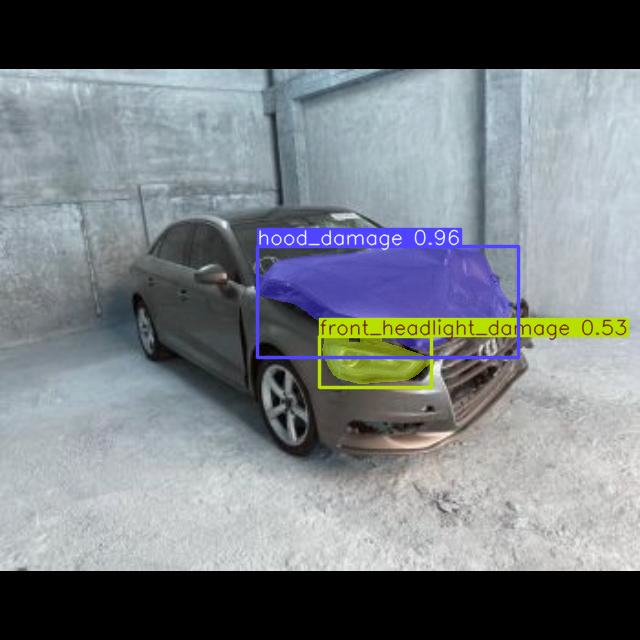

In [ ]:
rs[0].plot()

In [ ]:
# YOLO 모델 활용
# 이미지 1장, 여러장
# stream: youtube, video

# colab 환경의 특성상 영상데이터 다루기가 어려움
# 학습 완료된 모델 다운 -> 로컬 환경 연결해서 영상 자